<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/w4n2_simple_multiple_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 8- Simple & Multiple Linear Regression
### Statistics & Quantitative Methods for Data Science

Correlation (last class) tells us two variables move together. **Regression** goes further: it fits an equation that lets us *predict* one variable from another (or several others), and quantifies how much of the outcome's variation the predictors explain.

**This notebook:**
1. Simple linear regression, from scratch with NumPy
2. Fitting with `statsmodels` and interpreting the summary
3. R² — how much variance is explained
4. Multiple linear regression
5. Interpreting coefficients (holding other variables constant)
6. Checking regression assumptions
7. Multicollinearity (VIF)
8. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Simple linear regression, from scratch

We model $y = \beta_0 + \beta_1 x + \varepsilon$. The **ordinary least squares (OLS)** method picks $\beta_0, \beta_1$ to minimize the sum of squared residuals. Closed-form solution:

$$\beta_1 = \frac{\sum (x_i-\bar x)(y_i - \bar y)}{\sum (x_i - \bar x)^2}, \qquad \beta_0 = \bar y - \beta_1 \bar x$$

We'll predict `fare` from `pclass` (lower class number = higher fare, from last class's correlation analysis).

In [ ]:
df = titanic.dropna(subset=['pclass', 'fare']).copy()
x = df['pclass'].to_numpy(dtype=float)
y = df['fare'].to_numpy(dtype=float)

beta1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean())**2)
beta0 = y.mean() - beta1 * x.mean()

print(f"fare = {beta0:.2f} + ({beta1:.2f}) * pclass")
print(f"Predicted fare for pclass=1: {beta0 + beta1*1:.2f}")
print(f"Predicted fare for pclass=3: {beta0 + beta1*3:.2f}")

fare = 107.61 + (-32.66) * pclass
Predicted fare for pclass=1: 74.95
Predicted fare for pclass=3: 9.62


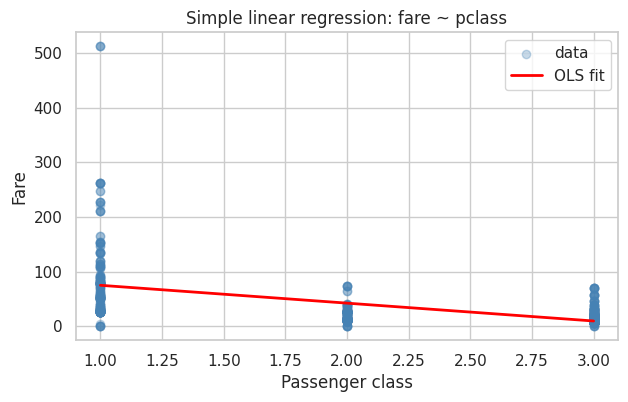

In [ ]:
plt.scatter(x, y, alpha=0.3, color='steelblue', label='data')
x_line = np.linspace(1, 3, 10)
plt.plot(x_line, beta0 + beta1*x_line, color='red', linewidth=2, label='OLS fit')
plt.xlabel('Passenger class'); plt.ylabel('Fare'); plt.legend()
plt.title('Simple linear regression: fare ~ pclass')
plt.show()

---
# 2. Fitting with `statsmodels`

In practice we use a library rather than hand-deriving coefficients — `statsmodels` also gives us standard errors, t-tests on each coefficient, and R² for free. Note the connection to Week 3: each coefficient comes with its own hypothesis test ($H_0$: this coefficient is 0, i.e. this predictor has no linear effect).

In [ ]:
X = sm.add_constant(df['pclass'])   # adds the intercept term
model = sm.OLS(df['fare'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     384.5
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.97e-71
Time:                        02:58:59   Log-Likelihood:                -4583.8
No. Observations:                 891   AIC:                             9172.
Df Residuals:                     889   BIC:                             9181.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        107.6057      4.089     26.315      0.0

Reading the summary:
- **coef**: matches our hand-computed $\beta_0, \beta_1$
- **P>|t|**: p-value testing $H_0$: this coefficient = 0 — here, essentially 0, so `pclass` is a significant predictor of `fare`
- **R-squared**: covered next

---
# 3. R² — variance explained

$$R^2 = 1 - \frac{\text{SS}_{\text{residual}}}{\text{SS}_{\text{total}}} = 1 - \frac{\sum(y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2}$$

Interpreted as "the proportion of variance in $y$ explained by the model." $R^2=1$: perfect fit. $R^2=0$: model does no better than just predicting the mean every time.

In [ ]:
y_pred = model.predict(X)
ss_res = np.sum((df['fare'] - y_pred)**2)
ss_tot = np.sum((df['fare'] - df['fare'].mean())**2)
r2_manual = 1 - ss_res/ss_tot

print(f"Manual R^2:      {r2_manual:.4f}")
print(f"statsmodels R^2: {model.rsquared:.4f}")
print(f"-> pclass alone explains about {model.rsquared:.0%} of the variance in fare; the rest is other factors + noise.")

Manual R^2:      0.3019
statsmodels R^2: 0.3019
-> pclass alone explains about 30% of the variance in fare; the rest is other factors + noise.


---
# 4. Multiple linear regression

Add more predictors to explain more of the variance. We model:

$$\text{fare} = \beta_0 + \beta_1 \cdot \text{pclass} + \beta_2 \cdot \text{age} + \beta_3 \cdot \text{sibsp} + \varepsilon$$

In [ ]:
df_multi = titanic.dropna(subset=['pclass', 'age', 'sibsp', 'fare']).copy()
X_multi = sm.add_constant(df_multi[['pclass', 'age', 'sibsp']])
y_multi = df_multi['fare']

model_multi = sm.OLS(y_multi, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     123.3
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           2.86e-64
Time:                        02:58:59   Log-Likelihood:                -3696.6
No. Observations:                 714   AIC:                             7401.
Df Residuals:                     710   BIC:                             7420.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        121.8853      7.347     16.590      0.0

---
# 5. Interpreting coefficients

Each coefficient in a multiple regression is interpreted **holding all other predictors constant**: "for each one-unit increase in `age`, fare changes by $\beta_{age}$, assuming `pclass` and `sibsp` stay fixed." This is different from — and usually smaller than — the *simple* regression coefficient on the same variable, because some of that variable's apparent effect may really be shared with the other predictors.

In [ ]:
print("Simple regression (fare ~ pclass only):")
print(f"  pclass coefficient: {model.params['pclass']:.2f}")
print("\nMultiple regression (fare ~ pclass + age + sibsp):")
print(model_multi.params.round(2))
print("\n-> The pclass coefficient barely moves here, meaning age and sibsp add mostly independent information rather than overlapping with pclass.")

Simple regression (fare ~ pclass only):
  pclass coefficient: -32.66

Multiple regression (fare ~ pclass + age + sibsp):
const     121.89
pclass    -37.39
age        -0.27
sibsp       8.83
dtype: float64

-> The pclass coefficient barely moves here, meaning age and sibsp add mostly independent information rather than overlapping with pclass.


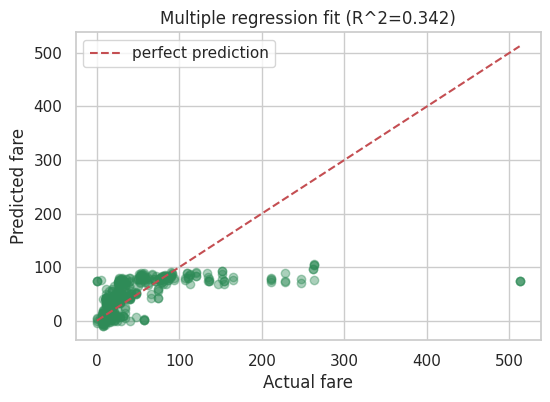

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(y_multi, model_multi.predict(X_multi), alpha=0.4, color='seagreen')
lims = [0, max(y_multi.max(), model_multi.predict(X_multi).max())]
ax.plot(lims, lims, 'r--', label='perfect prediction')
ax.set_xlabel('Actual fare'); ax.set_ylabel('Predicted fare'); ax.legend()
ax.set_title(f'Multiple regression fit (R^2={model_multi.rsquared:.3f})')
plt.show()

---
# 6. Checking regression assumptions

OLS regression relies on a few key assumptions — violating them badly means the coefficients, p-values, or intervals can't be trusted:

1. **Linearity** — the relationship really is (approximately) linear
2. **Independence** of residuals
3. **Homoscedasticity** — residual variance is roughly constant across predicted values (not "funnel-shaped")
4. **Normality** of residuals (mainly matters for small samples / inference, less for prediction)

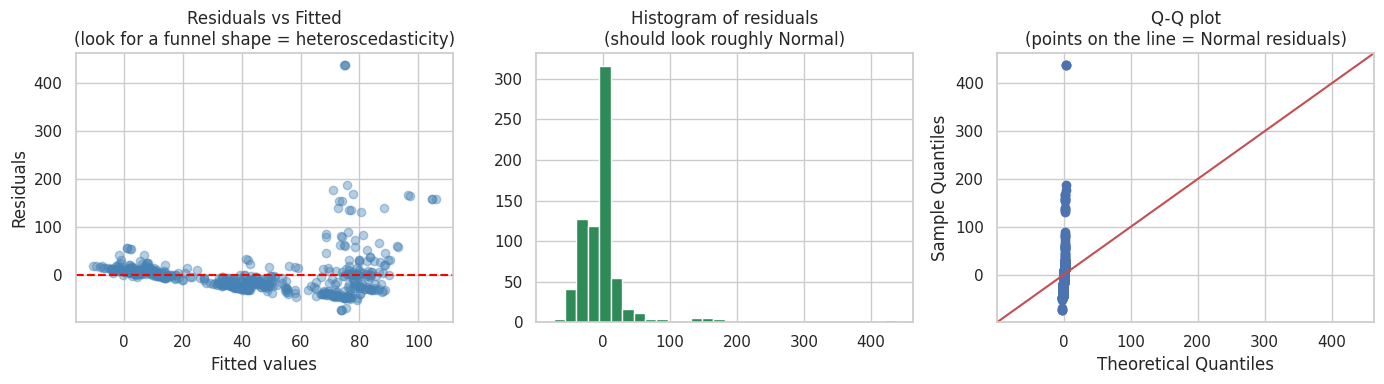

In [ ]:
residuals = model_multi.resid
fitted = model_multi.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(look for a funnel shape = heteroscedasticity)')

axes[1].hist(residuals, bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Histogram of residuals\n(should look roughly Normal)')

sm.qqplot(residuals, line='45', ax=axes[2])
axes[2].set_title('Q-Q plot\n(points on the line = Normal residuals)')

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats as sci_stats
shapiro_stat, shapiro_p = sci_stats.shapiro(residuals)
print(f"Shapiro-Wilk test on residuals: stat={shapiro_stat:.4f}, p={shapiro_p:.2e}")
print("Residuals significantly deviate from Normal (common with real, messy data like fare's skew)."
      if shapiro_p < 0.05 else "No significant deviation from Normal residuals.")

Shapiro-Wilk test on residuals: stat=0.5840, p=4.18e-38
Residuals significantly deviate from Normal (common with real, messy data like fare's skew).


The funnel shape and the skewed histogram both point to the same underlying issue we already knew about: `fare` itself is heavily right-skewed (Week 1). A common fix is modelling `log(fare)` instead — try it in the exercises.

---
# 7. Multicollinearity

When predictors are highly correlated with **each other** (not just with the outcome), their individual coefficients become unstable and hard to interpret — this is **multicollinearity**. The **Variance Inflation Factor (VIF)** measures it for each predictor; VIF > 5-10 is typically flagged as concerning.

In [ ]:
X_vif = df_multi[['pclass', 'age', 'sibsp']]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)
print("\n-> All VIFs well under 5: pclass, age and sibsp are not meaningfully redundant with each other here.")

  feature       VIF
0   const  1.000000
1  pclass  1.161068
2     age  1.277169
3   sibsp  1.108066

-> All VIFs well under 5: pclass, age and sibsp are not meaningfully redundant with each other here.


---
# 8. Exercises

1. Fit a simple regression of `fare` on `age` alone. Is `age` a significant predictor on its own? Compare its R² to the `pclass`-only model.
2. Add `parch` (parents/children aboard) to the multiple regression from Section 4. Does R² improve? Is `parch`'s coefficient statistically significant?
3. Fit the multiple regression again using `np.log1p(fare)` as the target instead of raw `fare`. Re-examine the residual plots from Section 6 — do they look better behaved?
4. Compute VIF for a model that includes both `sibsp` and `parch` together. Are they collinear with each other (makes sense: both relate to family size)?
5. **Challenge**: Build a regression predicting `age` from `pclass`, `fare`, and `sibsp`. Which predictor has the largest *standardized* effect? (Hint: standardize each predictor with a z-score first, so coefficients become comparable regardless of original units.)
